In [1]:
# import os
# os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
# import tensorflow as tf
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
# from tensorflow.keras.applications import MobileNetV2
# import os

# import numpy as np
# from sklearn.utils.class_weight import compute_class_weight

# from tensorflow.keras.regularizers import l2
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# from tensorflow.keras.layers import BatchNormalization

import tensorflow as tf
import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from keras.applications import MobileNetV2
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

In [3]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.15.0
GPU available: []


In [4]:
# DATA_DIR = "data/split"
DATA_DIR = "../data/split"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 40


In [5]:
# train_gen = ImageDataGenerator(
#     rescale=1./255,
    
#     # Geometric transformations
#     rotation_range=40,           # 20 -> 40 (xoay mạnh hơn)
#     width_shift_range=0.2,       # 0.1 -> 0.2 (dịch ngang)
#     height_shift_range=0.2,      # 0.1 -> 0.2 (dịch dọc)
#     shear_range=0.2,             # (biến dạng)
#     zoom_range=0.3,              # 0.2 → 0.3 (zoom)
#     horizontal_flip=True,
#     vertical_flip=True,          # (lật dọc)
    
#     # Color/brightness augmentation
#     brightness_range=[0.7, 1.3], # Thay đổi độ sáng ±30%
#     fill_mode='nearest'          # Cách fill pixel khi transform
# )

# val_gen = ImageDataGenerator(rescale=1./255)

# val_gen = ImageDataGenerator(rescale=1./255)

# print(" Augmentation config:")
# print("  - Rotation: ±40°")
# print("  - Shift: ±20%")
# print("  - Zoom: ±30%")
# print("  - Brightness: ±30%")
# print("  - Flips: horizontal + vertical")

# Data đã augment offline -> Chỉ cần rescale
# print(" Using pre-augmented dataset")
# print("   -> Runtime augmentation: MINIMAL (chỉ flip)")

train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,    #  Chỉ giữ flip (đơn giản, nhanh)
    #  Bỏ: rotation, shift, zoom, brightness
    # Lý do: Đã augment offline rồi, không cần augment mạnh runtime
    #  # Geometric
    # rotation_range=45,           # Tăng lên 45°
    # width_shift_range=0.25,      # Tăng lên 25%
    # height_shift_range=0.25,
    # shear_range=0.25,            # Thêm shear
    # zoom_range=0.25,
    # horizontal_flip=True,
    # vertical_flip=True,
    
    # # Color
    # brightness_range=[0.6, 1.4],  # Tăng range
    # fill_mode='nearest'
)

val_gen = ImageDataGenerator(rescale=1./255)

In [6]:
train_data = train_gen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_data = val_gen.flow_from_directory(
    os.path.join(DATA_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)


Found 20287 images belonging to 9 classes.
Found 4347 images belonging to 9 classes.


In [7]:
# Đếm số samples mỗi class trong train set
class_counts = {}
for class_name, class_idx in train_data.class_indices.items():
    class_dir = os.path.join(DATA_DIR, "train", class_name)
    count = len([f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[class_idx] = count

print("\n" + "="*70)
print("CLASS DISTRIBUTION (Training Set)")
print("="*70)

total_samples = sum(class_counts.values())
for class_name, class_idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
    count = class_counts[class_idx]
    percentage = count / total_samples * 100
    bar = "█" * int(percentage / 2)  # Visual bar
    print(f"{class_name:25s}: {count:5d} ({percentage:5.1f}%) {bar}")

# Tính class weights tự động (cân bằng)
classes = np.array(list(class_counts.keys()))
samples = np.array(list(class_counts.values()))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=np.repeat(classes, samples)
)

# Convert to dict
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("\n" + "="*70)
print("CLASS WEIGHTS (Higher = More Important)")
print("="*70)
for class_name, class_idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
    weight = class_weight_dict[class_idx]
    stars = "x" * int(weight * 2)  # Visual indicator
    print(f"{class_name:25s}: {weight:6.3f} {stars}")

print("\n Classes với ít samples sẽ có weight cao hơn")
print("   -> Model sẽ chú ý nhiều hơn vào những class này khi training")


CLASS DISTRIBUTION (Training Set)
bacterial_blight         :  2835 ( 14.0%) ██████
barrow_brown_leaf_spot   :  1432 (  7.1%) ███
brown_spot               :  3588 ( 17.7%) ████████
healthy                  :  2894 ( 14.3%) ███████
leaf_blast               :  3525 ( 17.4%) ████████
leaf_scald               :  2125 ( 10.5%) █████
leaf_smut                :   233 (  1.1%) 
rice_hispa               :  1411 (  7.0%) ███
sheath_blight            :  2244 ( 11.1%) █████

CLASS WEIGHTS (Higher = More Important)
bacterial_blight         :  0.795 x
barrow_brown_leaf_spot   :  1.574 xxx
brown_spot               :  0.628 x
healthy                  :  0.779 x
leaf_blast               :  0.639 x
leaf_scald               :  1.061 xx
leaf_smut                :  9.674 xxxxxxxxxxxxxxxxxxx
rice_hispa               :  1.598 xxx
sheath_blight            :  1.005 xx

 Classes với ít samples sẽ có weight cao hơn
   -> Model sẽ chú ý nhiều hơn vào những class này khi training


In [8]:
print("Label mapping:")
print(train_data.class_indices)


Label mapping:
{'bacterial_blight': 0, 'barrow_brown_leaf_spot': 1, 'brown_spot': 2, 'healthy': 3, 'leaf_blast': 4, 'leaf_scald': 5, 'leaf_smut': 6, 'rice_hispa': 7, 'sheath_blight': 8}


In [9]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


In [10]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    # Dense(128, activation="relu"),
    # Dropout(0.3),
    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(train_data.num_classes, activation="softmax")
])


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [12]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                        

In [13]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,  # tự restore về epoch tốt nhất
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "../models/rice_disease_best.keras",  # dùng .keras thay .h5
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [14]:
# history = model.fit(
#     train_data,
#     validation_data=val_data,
#     epochs=EPOCHS
# )

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks  
)

print("\n Training hoàn tất với class weights!")

Epoch 1/40


317/317 [==============================] - ETA: 0s - loss: 2.4523 - accuracy: 0.2760   
Epoch 1: val_accuracy improved from -inf to 0.50334, saving model to ../models\rice_disease_best.keras
317/317 [==============================] - 376s 1s/step - loss: 2.4523 - accuracy: 0.2760 - val_loss: 1.6589 - val_accuracy: 0.5033 - lr: 1.0000e-04
Epoch 2/40
317/317 [==============================] - ETA: 0s - loss: 1.7353 - accuracy: 0.4462  
Epoch 2: val_accuracy improved from 0.50334 to 0.57580, saving model to ../models\rice_disease_best.keras
317/317 [==============================] - 206s 649ms/step - loss: 1.7353 - accuracy: 0.4462 - val_loss: 1.4442 - val_accuracy: 0.5758 - lr: 1.0000e-04
Epoch 3/40
317/317 [==============================] - ETA: 0s - loss: 1.4938 - accuracy: 0.5197  
Epoch 3: val_accuracy improved from 0.57580 to 0.62572, saving model to ../models\rice_disease_best.keras
317/317 [==============================] - 213s 673ms/step - loss: 1.4938 - accuracy: 0

In [15]:
# os.makedirs("models", exist_ok=True)

# model.save("models/rice_disease_classifier.h5")
# print(" Model saved!")

os.makedirs("../models", exist_ok=True)
# Lưu 3 format để phòng hờ
# Format 1: .keras (native Keras 3, ổn định nhất cho môi trường cùng version)
model.save("../models/rice_disease_classifier.keras")

# Format 2: SavedModel (ổn định nhất cross-version, dùng cho VPS)
model.export("../models/rice_disease_savedmodel")

# Format 3: .h5 giữ lại để backward compatible
model.save("../models/rice_disease_classifier.h5")

print("Saved: .keras, SavedModel, .h5")

INFO:tensorflow:Assets written to: ../models/rice_disease_savedmodel\assets


INFO:tensorflow:Assets written to: ../models/rice_disease_savedmodel\assets


Saved artifact at '../models/rice_disease_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='mobilenetv2_1.00_224_input')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  1322721701632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739238336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739239568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739240800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739242032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739236928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739247488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739247136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739252944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322739249600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132

C:\Users\qahhn\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved: .keras, SavedModel, .h5


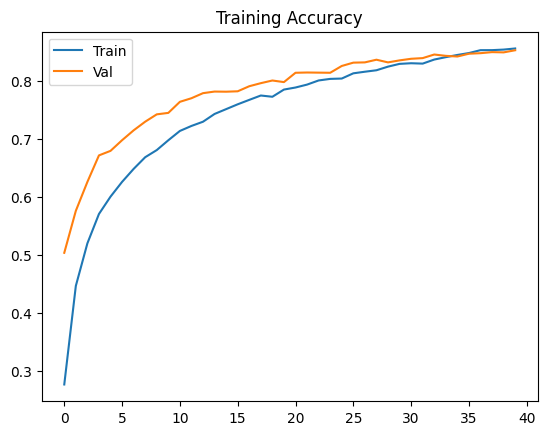

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("Training Accuracy")
plt.show()
